# Evaluation of Optimized schedulers

In [29]:
from pathlib import Path
import sys
# Project root = folder that contains Data/ (and preprocessor/, forecast_models/)
ROOT = Path.cwd() if (Path.cwd() / "Data").exists() else Path.cwd().parent
if not (ROOT / "Data").exists():
    raise FileNotFoundError("Data folder not found. Run notebook from project root or forecast_implementation.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from energy_components import *
from typing import Optional, Tuple
import pandas as pd
from helper import draw
import itertools
import cvxpy as cp
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
import gurobipy
import gymnasium as gym
from Schedulers import *
from Optimization import check_results,count_switch_ons

### **Input Prices**

In [30]:
# Input data
gas_price = 0.11 # EUR/Kwh
grid_price = 0.3 # EUR/Kwh
feed_in_price = .065 # EUR/Kwh

### **Input Components**

In [31]:
# Input components
pv = PV(name="PV",capacity=110)

boiler = Boiler(name="Boiler",
                capacity=150,
                rated_input_heat=167)

chp = CHP(name="CHP",capacity=43.33,
            rated_output_elec=13,
            rated_output_heat=26)

battery = Battery(name="Battery",capacity=60,
                    soc_elec=30,
                    max_charge_rate_elec=30,
                    max_discharge_rate_elec=30,
                    eta_charge_elec=.99,
                    eta_discharge_elec=.99)

buffer = Buffer(name="Buffer", capacity=100,
                 soc_heat=50,
                 eta_charge_heat=.99,
                 eta_discharge_heat=.99)

ee = ElectricHeatingElement(name="ee", capacity=30, conv_efficiency=.99)

components = {
    "boiler": boiler,
    "chp": chp,
    "ee": ee,
    "pv": pv,
    "buffer":buffer,
    "battery":battery,
}

### **Input Data**

In [32]:
DATA_DIR = ROOT / "Data"
df_hour = pd.read_csv(DATA_DIR / "gas_electricity_hourly.csv", index_col=0, parse_dates=True)

In [33]:
generated_pv = pd.read_csv(DATA_DIR / "pv_generated_hourly.csv", index_col=0, parse_dates=True)

generated_pv = generated_pv[["Wert"]]

In [34]:
generated_pv.max()

Wert    66.270355
dtype: float64

In [35]:
elec_demand_series = df_hour["elecmeter"]
gas_demand_series = df_hour["gasmeter"]  

In [36]:
date_time_index = df_hour.index

In [37]:
gas_demand_series

2024-01-01 00:00:00    114.93
2024-01-01 01:00:00     90.00
2024-01-01 02:00:00    104.03
2024-01-01 03:00:00    112.97
2024-01-01 04:00:00    103.07
                        ...  
2024-12-31 19:00:00    110.03
2024-12-31 20:00:00    110.07
2024-12-31 21:00:00    117.93
2024-12-31 22:00:00     82.04
2024-12-31 23:00:00     87.96
Name: gasmeter, Length: 8784, dtype: float64

In [38]:
elec_demand_series

2024-01-01 00:00:00     6.736869
2024-01-01 01:00:00     5.390000
2024-01-01 02:00:00     5.149623
2024-01-01 03:00:00     6.573508
2024-01-01 04:00:00     5.140000
                         ...    
2024-12-31 19:00:00    12.194115
2024-12-31 20:00:00    11.726492
2024-12-31 21:00:00    12.120000
2024-12-31 22:00:00    11.380377
2024-12-31 23:00:00    12.730000
Name: elecmeter, Length: 8784, dtype: float64

In [ ]:
dt = DigitalTwin(components)
dt.create_rule(name="Baseline")(Baseline_edited)
rule_name = "Baseline"
components = components
date_time_index = df_hour.index
pv_generated = generated_pv["Wert"]


baseline_load, baseline_gas_price, baseline_elec_price = dt.simulate_twin(rule_name,components,date_time_index,elec_demand = elec_demand_series, gas_demand = gas_demand_series,
                                                                           pv_generated =pv_generated,gas_price = gas_price,grid_price = grid_price,feed_in_price = feed_in_price)

In [40]:
baseline_gas_cost = baseline_gas_price["gas_price_total"].sum()
print("total gas cost: ", baseline_gas_cost)
baseline_elec_cost = baseline_elec_price["elec_price_total"].sum()
print("total electricity cost: ", baseline_elec_cost)
# baseline switching cost
switch_baseline =pd.DataFrame(baseline_load)[["boiler_in_total","chp_in"]]
switch_baseline.index = date_time_index
total_cost3a = baseline_gas_cost + baseline_elec_cost
switch_cost = count_switch_ons(switch_baseline,columns=["boiler_in_total","chp_in"]).sum()*10
print("switch cost: ", switch_cost)
print("total cost: ", total_cost3a + switch_cost)

total gas cost:  82827.76999999999
total electricity cost:  16831.64
switch cost:  6640
total cost:  106299.40999999999


In [41]:
baseline_check = pd.DataFrame(baseline_load)
baseline_check["elec_demand"] = elec_demand_series.values
baseline_check["gas_demand"] = gas_demand_series.values
baseline_check["pv_gen"] = pv_generated.values

In [ ]:
#baseline_result_check = check_results(baseline_check,components=components)

### **Sensitivity Analysis**

**Effect of Initializing SOC**

In [ ]:
soc_values_batt = [0,10,30,40,60]
soc_values_buff = [0,20,50,70,100]

In [49]:
rows = []
for soc_elec, soc_heat in itertools.product(soc_values_batt, soc_values_buff):
    battery = Battery(name="Battery", capacity=60, soc_elec=soc_elec,
                     max_charge_rate_elec=30, max_discharge_rate_elec=30,
                     eta_charge_elec=0.99, eta_discharge_elec=0.99)
    buffer = Buffer(name="Buffer", capacity=100, soc_heat=soc_heat,
                   eta_charge_heat=0.99, eta_discharge_heat=0.99)
    comps = {"boiler": boiler, "chp": chp, "ee": ee, "pv": pv, "buffer": buffer, "battery": battery}
    rule_name = "Baseline"
    components = comps
    date_time_index = df_hour.index
    pv_generated = generated_pv["Wert"]


    baseline_load, baseline_gas_price, baseline_elec_price = dt.simulate_twin(rule_name,components,date_time_index,elec_demand = elec_demand_series, gas_demand = gas_demand_series,
                                                                            pv_generated =pv_generated,gas_price = gas_price,grid_price = grid_price,feed_in_price = feed_in_price)

    gas_cost = baseline_gas_price["gas_price_total"].sum()
    elec_cost = baseline_elec_price["elec_price_total"].sum()
    switch_df = pd.DataFrame(baseline_load)[["boiler_in_total", "chp_in"]]
    n_switches = count_switch_ons(switch_df, columns=["boiler_in_total", "chp_in"]).sum()
    switch_cost = n_switches * 10
    total_price = gas_cost + elec_cost + switch_cost
    rows.append({
        "soc_elec": soc_elec,
        "soc_heat": soc_heat,
        "gas_cost": gas_cost,
        "elec_cost": elec_cost,
        "switch_cost": switch_cost,
        "n_switches": n_switches,
        "total_price": total_price,
    })

    
sensitivity_df_soc = pd.DataFrame(rows)
sensitivity_df_soc.describe()[["gas_cost","elec_cost","switch_cost","total_price"]]


,gas_cost,elec_cost,switch_cost,total_price
count,25.000000,25.00,25.0,25.000000
mean,82828.229200,16831.64,6640.0,106299.869200
std,5.146904,0.00,0.0,5.146904
min,82817.950000,16831.64,6640.0,106289.590000
25%,82824.110000,16831.64,6640.0,106295.750000
50%,82827.770000,16831.64,6640.0,106299.410000
75%,82831.410000,16831.64,6640.0,106303.050000
max,82837.460000,16831.64,6640.0,106309.100000


In [53]:
sensitivity_df_soc.describe().round(1)

,soc_elec,soc_heat,gas_cost,elec_cost,switch_cost,n_switches,total_price
count,25.0,25.0,25.0,25.0,25.0,25.0,25.0
mean,28.0,48.0,82828.2,16831.6,6640.0,664.0,106299.9
std,21.8,36.2,5.1,0.0,0.0,0.0,5.1
min,0.0,0.0,82818.0,16831.6,6640.0,664.0,106289.6
25%,10.0,20.0,82824.1,16831.6,6640.0,664.0,106295.7
50%,30.0,50.0,82827.8,16831.6,6640.0,664.0,106299.4
75%,40.0,70.0,82831.4,16831.6,6640.0,664.0,106303.0
max,60.0,100.0,82837.5,16831.6,6640.0,664.0,106309.1


In [56]:
# Format numeric columns: round and add thousand separators
def format_for_csv(df, decimal_places=2):
    out = df.copy()
    for col in out.select_dtypes(include=["number"]).columns:
        if out[col].dtype in ("int64", "int32"):
            out[col] = out[col].apply(lambda x: f"{int(x):,}")
        else:
            out[col] = out[col].apply(lambda x: f"{x:,.{decimal_places}f}")
    return out

sensitivity_df_formatted = format_for_csv(sensitivity_df_soc.describe().round(1), decimal_places=2)
sensitivity_df_formatted

,soc_elec,soc_heat,gas_cost,elec_cost,switch_cost,n_switches,total_price
count,25.00,25.00,25.00,25.00,25.00,25.00,25.00
mean,28.00,48.00,"82,828.20","16,831.60","6,640.00",664.00,"106,299.90"
std,21.80,36.20,5.10,0.00,0.00,0.00,5.10
min,0.00,0.00,"82,818.00","16,831.60","6,640.00",664.00,"106,289.60"
25%,10.00,20.00,"82,824.10","16,831.60","6,640.00",664.00,"106,295.70"
50%,30.00,50.00,"82,827.80","16,831.60","6,640.00",664.00,"106,299.40"
75%,40.00,70.00,"82,831.40","16,831.60","6,640.00",664.00,"106,303.00"
max,60.00,100.00,"82,837.50","16,831.60","6,640.00",664.00,"106,309.10"


In [61]:
sensitivity_df_formatted.to_csv(DATA_DIR/"sensitivity_statistic_SOC.csv")

**Effect of charging battery/buffer to a desired SOC**

In [66]:
charge_at = [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1]
battery = Battery(name="Battery",capacity=60,
                    soc_elec=30,
                    max_charge_rate_elec=30,
                    max_discharge_rate_elec=30,
                    eta_charge_elec=.99,
                    eta_discharge_elec=.99)

buffer = Buffer(name="Buffer", capacity=100,
                 soc_heat=50,
                 eta_charge_heat=.99,
                 eta_discharge_heat=.99)
comps = {"boiler": boiler, "chp": chp, "ee": ee, "pv": pv, "buffer": buffer, "battery": battery}
rows = []
for charge in charge_at:
    comps = {"boiler": boiler, "chp": chp, "ee": ee, "pv": pv, "buffer": buffer, "battery": battery}
    rule_name = "Baseline"
    components = comps
    date_time_index = df_hour.index
    pv_generated = generated_pv["Wert"]


    baseline_load, baseline_gas_price, baseline_elec_price = dt.simulate_twin(rule_name,components,date_time_index,elec_demand = elec_demand_series, gas_demand = gas_demand_series,
                                                                            pv_generated =pv_generated,gas_price = gas_price,grid_price = grid_price,feed_in_price = feed_in_price,charge_at = charge)

    gas_cost = baseline_gas_price["gas_price_total"].sum()
    elec_cost = baseline_elec_price["elec_price_total"].sum()
    switch_df = pd.DataFrame(baseline_load)[["boiler_in_total", "chp_in"]]
    n_switches = count_switch_ons(switch_df, columns=["boiler_in_total", "chp_in"]).sum()
    switch_cost = n_switches * 10
    total_price = gas_cost + elec_cost + switch_cost
    rows.append({
        "charge_at": charge,
        "gas_cost": gas_cost,
        "elec_cost": elec_cost,
        "switch_cost": switch_cost,
        "n_switches": n_switches,
        "total_price": total_price,
    })
sensitivity_df_charge = pd.DataFrame(rows)
sensitivity_df_charge

,charge_at,gas_cost,elec_cost,switch_cost,n_switches,total_price
0,0.0,82004.96,16776.57,7260,726,106041.53
1,0.1,82323.87,16804.49,6990,699,106118.36
2,0.2,82503.77,16808.19,6840,684,106151.96
3,0.3,82641.94,16813.72,6780,678,106235.66
4,0.4,82726.36,16823.82,6720,672,106270.18
5,0.5,82825.37,16831.64,6640,664,106297.01
6,0.6,82952.15,16830.62,6590,659,106372.77
7,0.7,83025.88,16836.22,6530,653,106392.10
8,0.8,83080.04,16841.74,6500,650,106421.78
9,0.9,83131.13,16842.03,6460,646,106433.16


In [67]:
sensitivity_df_charge[["charge_at","total_price","switch_cost"]]

,charge_at,total_price,switch_cost
0,0.0,106041.53,7260
1,0.1,106118.36,6990
2,0.2,106151.96,6840
3,0.3,106235.66,6780
4,0.4,106270.18,6720
5,0.5,106297.01,6640
6,0.6,106372.77,6590
7,0.7,106392.10,6530
8,0.8,106421.78,6500
9,0.9,106433.16,6460


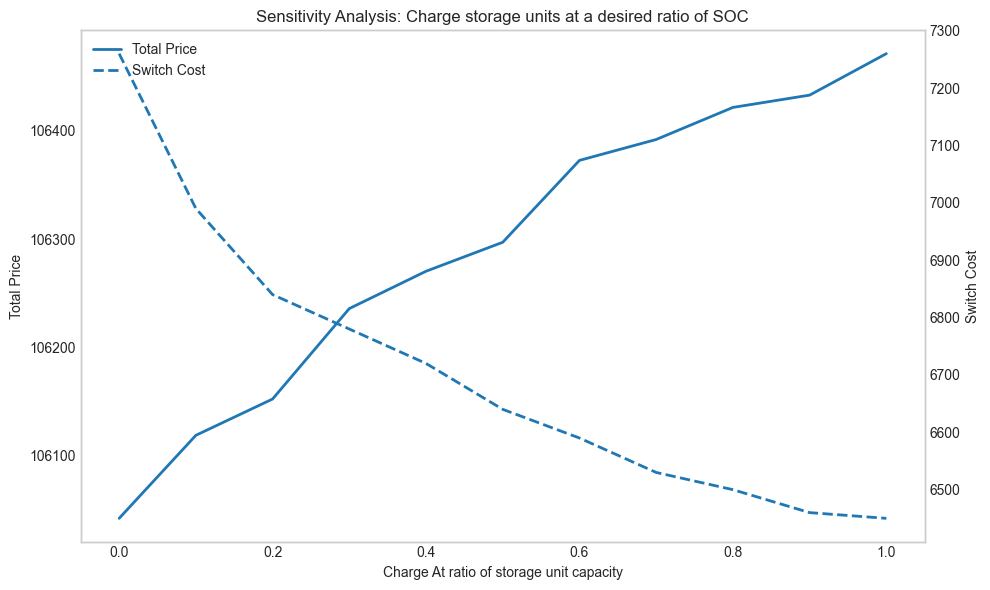

In [72]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

fig, ax1 = plt.subplots(figsize=(10, 6))

# First axis (left)
line1, = ax1.plot(
    sensitivity_df_charge["charge_at"],
    sensitivity_df_charge["total_price"],
    linewidth=2,
    label="Total Price"
)
ax1.set_xlabel("Charge At ratio of storage unit capacity")
ax1.set_ylabel("Total Price")
ax1.grid(False)
# Second axis (right)
ax2 = ax1.twinx()
ax2.grid(False)
line2, = ax2.plot(
    sensitivity_df_charge["charge_at"],
    sensitivity_df_charge["switch_cost"],
    linestyle="--",
    linewidth=2,
    label="Switch Cost"
)
ax2.set_ylabel("Switch Cost")

lines = [line1, line2]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="best")

plt.title("Sensitivity Analysis: Charge storage units at a desired ratio of SOC")
fig.tight_layout()
plt.show()

**Effect of storing heat from the boiler**

In [74]:
from_chp_only = [False,True]
battery = Battery(name="Battery",capacity=60,
                    soc_elec=30,
                    max_charge_rate_elec=30,
                    max_discharge_rate_elec=30,
                    eta_charge_elec=.99,
                    eta_discharge_elec=.99)

buffer = Buffer(name="Buffer", capacity=100,
                 soc_heat=50,
                 eta_charge_heat=.99,
                 eta_discharge_heat=.99)
comps = {"boiler": boiler, "chp": chp, "ee": ee, "pv": pv, "buffer": buffer, "battery": battery}
rows = []
for from_chp_on in from_chp_only:
    comps = {"boiler": boiler, "chp": chp, "ee": ee, "pv": pv, "buffer": buffer, "battery": battery}
    rule_name = "Baseline"
    components = comps
    date_time_index = df_hour.index
    pv_generated = generated_pv["Wert"]


    baseline_load, baseline_gas_price, baseline_elec_price = dt.simulate_twin(rule_name,components,date_time_index,elec_demand = elec_demand_series, gas_demand = gas_demand_series,
                                                                            pv_generated =pv_generated,gas_price = gas_price,grid_price = grid_price,feed_in_price = feed_in_price,chp_charge_only=from_chp_on)

    gas_cost = baseline_gas_price["gas_price_total"].sum()
    elec_cost = baseline_elec_price["elec_price_total"].sum()
    switch_df = pd.DataFrame(baseline_load)[["boiler_in_total", "chp_in"]]
    n_switches = count_switch_ons(switch_df, columns=["boiler_in_total", "chp_in"]).sum()
    switch_cost = n_switches * 10
    total_price = gas_cost + elec_cost + switch_cost
    rows.append({
        "from_chp_only": from_chp_on,
        "gas_cost": gas_cost,
        "elec_cost": elec_cost,
        "switch_cost": switch_cost,
        "n_switches": n_switches,
        "total_price": total_price,
    })
sensitivity_df_charge = pd.DataFrame(rows)
sensitivity_df_charge

,from_chp_only,gas_cost,elec_cost,switch_cost,n_switches,total_price
0,False,82827.77,16831.64,6640,664,106299.41
1,True,79042.45,16831.64,1940,194,97814.09
